<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hands_on_learning/hands_on_ml_with_scikit-learn_Aurelien_textbook/Chapter_4_Support_Vector_Machines_(Exercise).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
%pip install ipympl

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.7 MB/s eta 0:00:00


In [ ]:
%matplotlib widget
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
from sklearn.datasets import fetch_openml

In [ ]:
def get_path(*path):
  main_path = "/content/drive/My Drive/Machine_Learning/"
  generated_path = os.path.join(main_path, *path)
  return generated_path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# mnist = fetch_openml("mnist_784", version=1)
# joblib.dump(mnist, get_path("datasets", "mnist.pkl"))


In [ ]:
mnist = joblib.load(get_path("datasets", "mnist.pkl"))

In [ ]:
mnist_frame = mnist["frame"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(mnist_frame.drop("class", axis=1), mnist_frame["class"], train_size=60000, shuffle=False)

In [ ]:
def show_image(X, y, index):
    plt.figure()
    row_data = X.iloc[index].values.reshape(28, 28)
    plt.imshow(row_data, cmap=plt.get_cmap("jet"), vmin=0, vmax=255)
    plt.colorbar()
    plt.show()
    print("Corresponding target is: ", y.iloc[index])

In [ ]:
sample_loc = 0

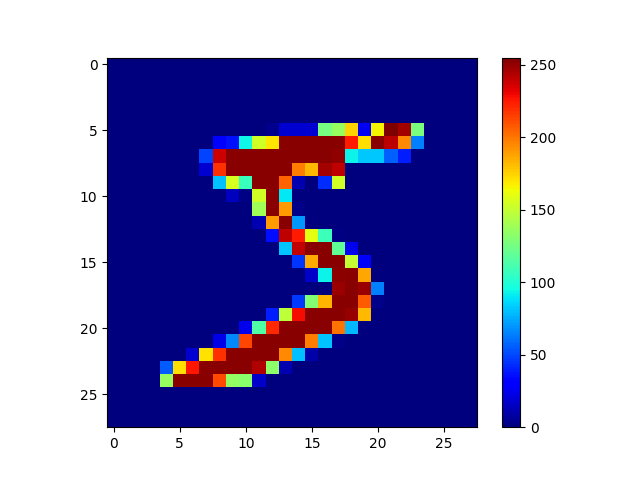

Corresponding target is:  5


In [ ]:
show_image(X_train, y_train, sample_loc)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [ ]:
# svm_clf = Pipeline([
#     ("scaler", StandardScaler()),
#     ("svg_model", SVC())
# ])
# svm_clf.fit(X_train, y_train)
# joblib.dump(svm_clf, get_path("Models", "svm_clf.pkl"))

In [ ]:
svm_clf = joblib.load(get_path("Models", "svm_clf.pkl"))

In [ ]:
# digits_predictions = svm_clf.predict(X_train)
# joblib.dump(digits_predictions, get_path("Models", "svm_digits_predictions"))

In [ ]:
digits_predictions = joblib.load( get_path("Models", "svm_digits_predictions"))

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [ ]:
confusion_matrix(y_train, digits_predictions)

array([[5896,    2,    0,    1,    1,    3,   10,    1,    8,    1],
       [   1, 6690,   16,    7,    5,    0,    1,    8,    5,    9],
       [   8,    6, 5898,    4,    9,    1,    1,   14,   14,    3],
       [   0,    7,   17, 6011,    3,   25,    0,   20,   36,   12],
       [   2,   10,    6,    0, 5763,    0,    7,    4,    2,   48],
       [   6,    3,    5,   32,    6, 5343,   16,    1,    7,    2],
       [  13,    5,    1,    0,    5,   12, 5877,    0,    5,    0],
       [   1,   21,   17,    3,   17,    0,    0, 6175,    1,   30],
       [   5,   26,    7,   22,    7,   15,    7,    7, 5749,    6],
       [   6,    8,    2,   29,   44,    5,    1,   46,   12, 5796]])

In [ ]:
print(recall_score(y_train, digits_predictions, average="weighted"), \
      precision_score(y_train, digits_predictions, average="weighted"), \
      accuracy_score(y_train, digits_predictions))

0.9866333333333334 0.9866279137208656 0.9866333333333334


In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores = cross_val_score(svm_clf, X_train, y_train)

In [ ]:
scores

array([0.96191667, 0.962     , 0.96308333, 0.95616667, 0.96566667])

In [ ]:
y_pred = svm_clf.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.966

In [ ]:
recall_score(y_test, y_pred, average=None)

array([0.9877551 , 0.99295154, 0.96511628, 0.96930693, 0.96130346,
       0.9573991 , 0.97077244, 0.96303502, 0.95071869, 0.93756194])

In [ ]:
confusion_matrix(y_test, y_pred)

array([[ 968,    0,    1,    1,    0,    3,    3,    2,    2,    0],
       [   0, 1127,    3,    0,    0,    1,    2,    0,    2,    0],
       [   5,    1,  996,    2,    2,    0,    1,   15,    9,    1],
       [   0,    0,    4,  979,    1,    7,    0,   12,    7,    0],
       [   0,    0,   12,    0,  944,    2,    4,    7,    3,   10],
       [   2,    0,    1,   10,    2,  854,    6,    8,    7,    2],
       [   6,    2,    1,    0,    4,    8,  930,    2,    5,    0],
       [   1,    6,   13,    2,    3,    0,    0,  990,    0,   13],
       [   3,    0,    4,    6,    6,    9,    3,   14,  926,    3],
       [   4,    6,    5,   11,   12,    2,    0,   20,    3,  946]])